# Following information for accessing KLIFS here:

Downloaded JSON files for relevnt kinases from here: https://mkt-app.streamlit.app/

https://github.com/choderalab/missense-kinase-toolkit?tab=readme-ov-file


In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
import json
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [49]:
cdks = ['CDK7', 'CDK8', 'CDK19', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']

#extracting KLIFS alignment AND phosphosite information

dfList = []
phosphosites = []

for cdk in cdks:
    file = f'../../source_data/16_KLIFS/{cdk}.json'
    #"KLIFS2UniProtIdx"

    # Load the JSON file
    with open(file, "r") as f:
        data = json.load(f)

    klifs = pd.DataFrame(list(data['KLIFS2UniProtIdx'].items()), columns=['KLIFS_idx', cdk])

    #load pocket sequence
    seq = list(data['klifs']['pocket_seq'])
    klifs[f'{cdk}_seq'] = seq

    ps = data['uniprot']['phospho_sites']

    dfList.append(klifs)
    phosphosites.append(ps)


from functools import reduce
comb_klifs = reduce(lambda x, y: pd.merge(x, y, on = 'KLIFS_idx'), dfList)

phosphosite_dict = dict(zip(cdks, phosphosites))

In [ ]:
#comb_klifs.to_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv', index=False)

In [50]:
comb_klifs

,KLIFS_idx,CDK7,CDK7_seq,CDK8,CDK8_seq,CDK19,CDK19_seq,CDK9,CDK9_seq,CDK12,CDK12_seq,CDK13,CDK13_seq,CDK2,CDK2_seq,CDK4,CDK4_seq,CDK6,CDK6_seq
0,I:1,16.0,D,25.0,C,25.0,C,23.0,A,731.0,G,709.0,G,8.0,E,10.0,A,17.0,A
1,I:2,17.0,F,26.0,K,26.0,K,24.0,K,732.0,I,710.0,I,9.0,K,11.0,E,18.0,E
2,I:3,18.0,L,27.0,V,27.0,V,25.0,I,733.0,I,711.0,I,10.0,I,12.0,I,19.0,I
3,g.l:4,19.0,G,28.0,G,28.0,G,26.0,G,734.0,G,712.0,G,11.0,G,13.0,G,20.0,G
4,g.l:5,20.0,E,29.0,R,29.0,R,27.0,Q,735.0,E,713.0,E,12.0,E,14.0,V,21.0,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,xDFG:81,155.0,D,173.0,D,173.0,D,167.0,D,877.0,D,855.0,D,145.0,D,158.0,D,163.0,D
81,xDFG:82,156.0,F,174.0,M,174.0,M,168.0,F,878.0,F,856.0,F,146.0,F,159.0,F,164.0,F
82,xDFG:83,157.0,G,175.0,G,175.0,G,169.0,G,879.0,G,857.0,G,147.0,G,160.0,G,165.0,G
83,a.l:84,158.0,L,176.0,F,176.0,F,170.0,L,880.0,L,858.0,L,148.0,L,161.0,L,166.0,L


In [51]:
phosphosite_dict

{'CDK7': [7, 164, 170, 321],
 'CDK8': None,
 'CDK19': [449],
 'CDK9': [175, 186, 347, 350, 353, 354, 357, 362, 363],
 'CDK12': [57,
  73,
  236,
  249,
  265,
  274,
  276,
  301,
  303,
  310,
  312,
  318,
  323,
  325,
  332,
  333,
  334,
  338,
  341,
  343,
  345,
  383,
  385,
  400,
  420,
  423,
  514,
  614,
  644,
  681,
  685,
  692,
  889,
  893,
  1053,
  1083,
  1244,
  1246],
 'CDK13': [315,
  317,
  325,
  340,
  342,
  358,
  360,
  383,
  395,
  397,
  400,
  437,
  439,
  525,
  588,
  871,
  1048,
  1058,
  1246],
 'CDK2': [14, 15, 19, 160],
 'CDK4': [172],
 'CDK6': [13, 24, 49, 70, 177, 325]}

In [17]:
data['uniprot']['phospho_sites']

[315,
 317,
 325,
 340,
 342,
 358,
 360,
 383,
 395,
 397,
 400,
 437,
 439,
 525,
 588,
 871,
 1048,
 1058,
 1246]

In [19]:
data['uniprot']['phospho_description']

['Phosphoserine',
 'Phosphoserine',
 'Phosphoserine',
 'Phosphoserine',
 'Phosphoserine',
 'Phosphoserine',
 'Phosphoserine',
 'Phosphoserine',
 'Phosphoserine',
 'Phosphoserine',
 'Phosphoserine',
 'Phosphoserine',
 'Phosphoserine',
 'Phosphoserine',
 'Phosphothreonine',
 'Phosphothreonine',
 'Phosphoserine',
 'Phosphothreonine',
 'Phosphothreonine']

In [ ]:
data['KLIFS2UniProtSeq']

{'I': 'AEI',
 'g.l': 'GEGAYG',
 'II': 'KVFK',
 'II:III': 'ARDLKNGGRF',
 'III': 'VALKRV',
 'III:αC': 'RVQTGEEGMPL',
 'αC': 'STIREVAVLRH',
 'b.l_1': 'LE',
 'b.l_intra': 'TFEH',
 'b.l_2': 'PNVVR',
 'IV': 'LFDV',
 'IV:V': 'CTVSRTDRETKL',
 'V': 'TLV',
 'GK': 'F',
 'hinge': 'EHV',
 'hinge:linker': None,
 'linker_1': 'D',
 'linker_intra': None,
 'linker_2': '-QD',
 'αD': 'LTTYLDK',
 'αD:αE': 'VPEPGVPTETIKDMMFQLLRGLD',
 'αE': 'FLHSH',
 'αE:VI': None,
 'VI': 'RVV',
 'c.l': 'HRDLKPQN',
 'VII': 'ILV',
 'VII:VIII': 'TSSGQIK',
 'VIII': 'L',
 'xDFG': 'ADFG',
 'a.l': 'LA'}

In [30]:
klifs = pd.DataFrame(list(data['KLIFS2UniProtIdx'].items()), columns=['KLIFS_idx', 'CDK13'])
klifs

,KLIFS_idx,CDK13
0,I:1,709.0
1,I:2,710.0
2,I:3,711.0
3,g.l:4,712.0
4,g.l:5,713.0
...,...,...
80,xDFG:81,855.0
81,xDFG:82,856.0
82,xDFG:83,857.0
83,a.l:84,858.0


In [29]:
klifs[:50]

,KLIFS_idx,CDK13
0,I:1,709.0
1,I:2,710.0
2,I:3,711.0
3,g.l:4,712.0
4,g.l:5,713.0
5,g.l:6,714.0
6,g.l:7,715.0
7,g.l:8,716.0
8,g.l:9,717.0
9,II:10,718.0


# visualization pyMSAviz

https://github.com/moshi4/pyMSAviz/blob/main/example/api_example_run.ipynb

In [55]:
cdks = ['CDK7', 'CDK8', 'CDK19', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']

#extracting KLIFS alignment AND phosphosite information
seq_list = []

for cdk in cdks:
    file = f'../../source_data/16_KLIFS/{cdk}.json'
    #"KLIFS2UniProtIdx"

    # Load the JSON file
    with open(file, "r") as f:
        data = json.load(f)

    klifs = pd.DataFrame(list(data['KLIFS2UniProtIdx'].items()), columns=['KLIFS_idx', cdk])

    #load pocket sequence
    seq = list(data['klifs']['pocket_seq'])
    seq_list.append(seq)

In [ ]:
filename = f'../../source_data/16_KLIFS/KLIFS.fa'
with open(filename, 'w') as f:
    for i, val in enumerate(seq_list):
        ss = ''.join(val)
        n = cdks[i]

        f.write(f">{n}\n")
        f.write(f"{ss}\n")


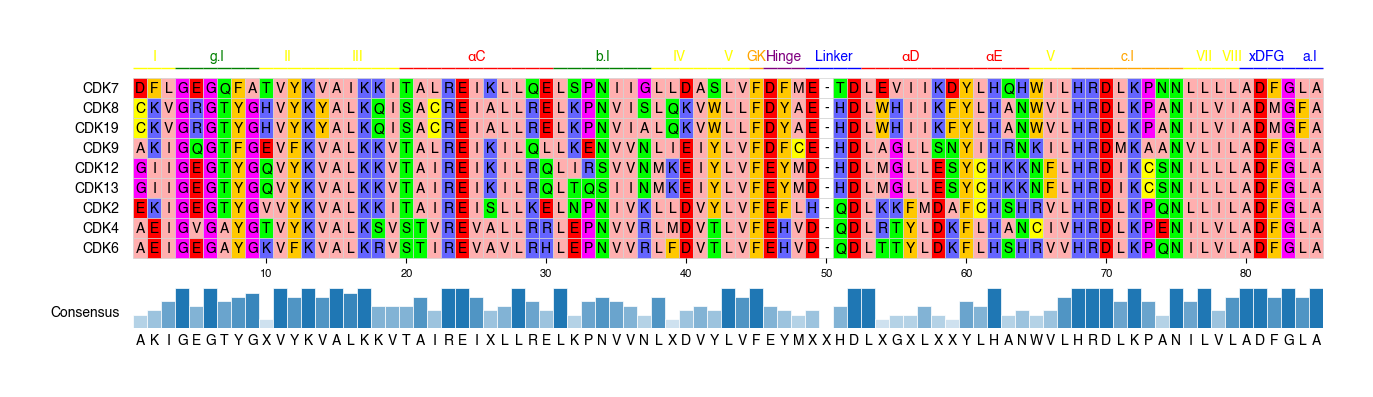

In [72]:
from pymsaviz import MsaViz, get_msa_testdata

#msa_file = get_msa_testdata("MRGPRG.fa")
mv = MsaViz(f'../../source_data/16_KLIFS/KLIFS.fa', wrap_length=85, show_grid=True, show_consensus=True)



mv.add_text_annotation((1, 3), "I", text_color="yellow", range_color="yellow")
mv.add_text_annotation((4, 9), "g.l", text_color="green", range_color="green")
mv.add_text_annotation((10, 13), "II", text_color="yellow", range_color="yellow")
mv.add_text_annotation((14, 19), "III", text_color="yellow", range_color="yellow")
mv.add_text_annotation((20, 30), "αC", text_color="red", range_color="red")
mv.add_text_annotation((31, 37), "b.l", text_color="green", range_color="green")
mv.add_text_annotation((38, 41), "IV", text_color="yellow", range_color="yellow")
mv.add_text_annotation((42, 44), "V", text_color="yellow", range_color="yellow")
mv.add_text_annotation((45,45), "GK", text_color="orange", range_color="orange")
mv.add_text_annotation((46,48), "Hinge", text_color="purple", range_color="purple")
mv.add_text_annotation((49,52), "Linker", text_color="blue", range_color="blue")
mv.add_text_annotation((53, 59), "αD", text_color="red", range_color="red")
mv.add_text_annotation((60, 64), "αE", text_color="red", range_color="red")
mv.add_text_annotation((65, 67), "V", text_color="yellow", range_color="yellow")
mv.add_text_annotation((68,75), "c.l", text_color="orange", range_color="orange")
mv.add_text_annotation((76, 78), "VII", text_color="yellow", range_color="yellow")
mv.add_text_annotation((79,79), "VIII", text_color="yellow", range_color="yellow")
mv.add_text_annotation((80,83), "xDFG", text_color="blue", range_color="blue")
mv.add_text_annotation((84,85), "a.l", text_color="blue", range_color="blue")

fig = mv.plotfig()